# Route-Specific Bias Feature

This notebook tests adding a route-specific bias feature (`route_mean_delay`) to account for routes with different baseline delay rates. The motivation arose from an observation that removing the Perth→Adelaide route (poor R²) counter-intuitively *decreases* the overall test R². This suggests the route's poor performance may be due to offset between overall mean delay rate and its route-specific delay rate. The hope is that by adding route mean delay as a feature, it allows the model to learn route-specific biases/offsets.

The approach here is to calculate historical mean delay rate per route (from training data only, to avoid leakage): `route_mean_delay`, which is the added as a feature.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, roc_auc_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed")

%matplotlib inline

XGBoost available


In [2]:
# Baseline metrics from notebook 8b (for comparison)
BASELINE_8B = {
    'regression': {
        'Ridge': {'val_r2': 0.4099, 'test_r2': 0.4618},
        'Random Forest': {'val_r2': 0.4148, 'test_r2': 0.4858}
    },
    'classification': {
        'Logistic': {'val_f1': 0.6821, 'test_f1': 0.7062},
        'Random Forest': {'val_f1': 0.7024, 'test_f1': 0.6963},
        'XGBoost': {'val_f1': 0.7139, 'test_f1': 0.7328}
    }
}
print("Baseline metrics loaded.")

Baseline metrics loaded.


## 1. Data Preparation

Replicate preprocessing from notebook 8b.

In [3]:
# Load multi-route data
df = pd.read_csv('../data/processed/ml_training_data_multiroute_hols.csv')

df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = df['year_month_dt'].dt.month
df['year'] = df['year'].astype(int)
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']
df['route'] = df['departing_port'] + '_' + df['arriving_port']
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print(f"Original shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")

Original shape: (16772, 62)
Date range: 2010-01 to 2025-11


In [4]:
# Filter low-volume airline-routes
volume_threshold = 40
airline_route_volume = df.groupby('airline_route')['sectors_scheduled'].mean().reset_index()
airline_route_volume.columns = ['airline_route', 'avg_volume']
high_volume_ar = airline_route_volume[airline_route_volume['avg_volume'] >= volume_threshold]['airline_route'].tolist()
df_filtered = df[df['airline_route'].isin(high_volume_ar)].copy()
print(f"Records after volume filtering (>={volume_threshold} flights/mo): {len(df_filtered)}")

Records after volume filtering (>=40 flights/mo): 13153


In [5]:
# Exclude anomalous routes (same as 8b)
anomalous_routes = ['Melbourne_Hobart', 'Adelaide_Sydney', 'Perth_Brisbane']
records_before = len(df_filtered)
df_filtered = df_filtered[~df_filtered['route'].isin(anomalous_routes)].copy()
print(f"Excluded anomalous routes: {anomalous_routes}")
print(f"Records before: {records_before}")
print(f"Records after:  {len(df_filtered)}")

Excluded anomalous routes: ['Melbourne_Hobart', 'Adelaide_Sydney', 'Perth_Brisbane']
Records before: 13153
Records after:  11633


In [6]:
# Feature engineering (same as 8b)
df_filtered['delay_rate_lag1'] = df_filtered.groupby('airline_route')['delay_rate'].shift(1)
df_filtered['delay_rate_lag2'] = df_filtered.groupby('airline_route')['delay_rate'].shift(2)
df_filtered['delay_rate_gradient'] = df_filtered['delay_rate_lag1'] - df_filtered['delay_rate_lag2']

df_filtered['month_sin'] = np.sin(2 * np.pi * df_filtered['month_num'] / 12)
df_filtered['month_cos'] = np.cos(2 * np.pi * df_filtered['month_num'] / 12)

airline_dummies = pd.get_dummies(df_filtered['airline'], prefix='airline')
df_filtered = pd.concat([df_filtered, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

route_dummies = pd.get_dummies(df_filtered['route'], prefix='route')
df_filtered = pd.concat([df_filtered, route_dummies], axis=1)
route_cols = list(route_dummies.columns)

df_filtered['rainy_days_arr_exp'] = np.exp(df_filtered['rainy_days_arr'] / df_filtered['rainy_days_arr'].max())
df_filtered['temp_volatility_total'] = df_filtered['temp_volatility_dep'] + df_filtered['temp_volatility_arr']
df_filtered['temp_volatility_total_exp'] = np.exp(df_filtered['temp_volatility_total'] / df_filtered['temp_volatility_total'].max())
df_filtered['extreme_weather_days_total'] = df_filtered['extreme_weather_days_dep'] + df_filtered['extreme_weather_days_arr']

df_clean = df_filtered.dropna(subset=['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_gradient']).copy()
print(f"Rows after dropping NaN: {len(df_clean)}")

Rows after dropping NaN: 11467


In [7]:
# Train/Validation/Test split (same as 8b)
train_mask = (((df_clean['year'] >= 2010) & (df_clean['year'] <= 2017)) | (df_clean['year'] == 2023))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2024))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2023): {train_mask.sum()} samples")
print(f"Val (2018, 2024):        {val_mask.sum()} samples")
print(f"Test (2019, 2025):       {test_mask.sum()} samples")

Train (2010-2017, 2023): 6835 samples
Val (2018, 2024):        1589 samples
Test (2019, 2025):       1451 samples


## 2. Investigate Route Variance

Before adding the feature, let's verify the hypothesis about Perth_Adelaide having low variance.

In [8]:
# Variance of delay_rate by route in test set
df_test_temp = df_clean[test_mask].copy()
route_stats = df_test_temp.groupby('route')['delay_rate'].agg(['mean', 'std', 'var', 'count']).round(4)
route_stats = route_stats.sort_values('var')

print("Route Delay Rate Statistics (Test Set):")
print("=" * 70)
print(route_stats)
print("\nLowest variance routes are candidates for benefiting from route mean feature.")

Route Delay Rate Statistics (Test Set):
                      mean     std     var  count
route                                            
Sydney_Brisbane     0.2563  0.0636  0.0040     81
Perth_Adelaide      0.1437  0.0758  0.0058     46
Melbourne_Sydney    0.2874  0.0829  0.0069     81
Perth_Melbourne     0.2272  0.0851  0.0072     81
Perth_Sydney        0.2054  0.0879  0.0077     46
Brisbane_Sydney     0.2677  0.0887  0.0079     81
Hobart_Sydney       0.2652  0.0925  0.0086     68
Melbourne_Adelaide  0.2545  0.0988  0.0098     81
Sydney_Melbourne    0.2862  0.0996  0.0099     81
Sydney_Adelaide     0.2369  0.1007  0.0101     69
Melbourne_Brisbane  0.2560  0.1053  0.0111     96
Adelaide_Perth      0.1676  0.1076  0.0116     46
Adelaide_Melbourne  0.2408  0.1094  0.0120     81
Sydney_Hobart       0.2265  0.1210  0.0147     68
Hobart_Melbourne    0.2886  0.1215  0.0148     74
Brisbane_Melbourne  0.2830  0.1230  0.0151     96
Sydney_Perth        0.2962  0.1281  0.0164     46
Brisbane_A

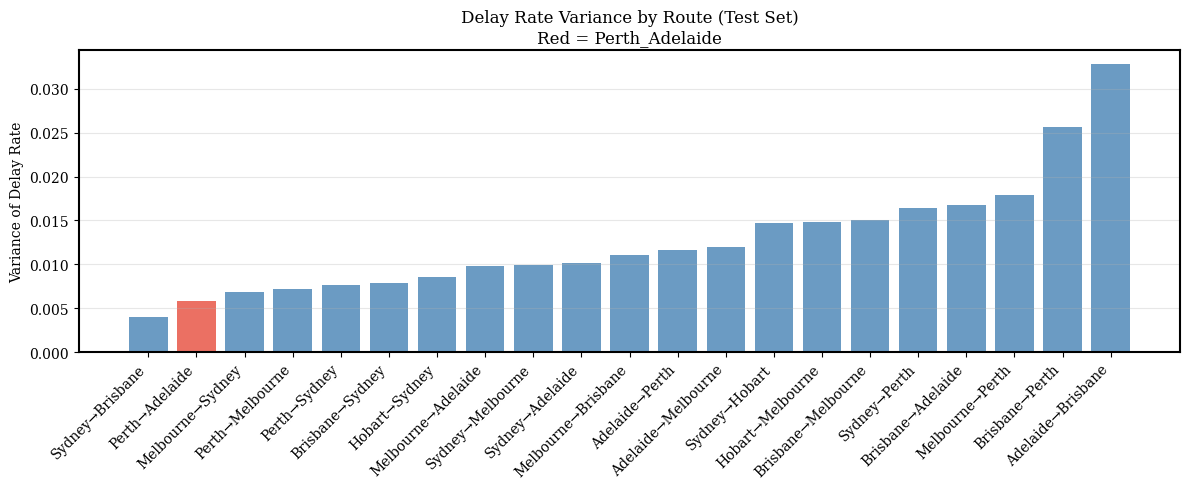

In [9]:
# Visualize variance by route
fig, ax = plt.subplots(figsize=(12, 5))

routes_sorted = route_stats.index.tolist()
variances = route_stats['var'].values

colors = ['#e74c3c' if 'Perth_Adelaide' in r else 'steelblue' for r in routes_sorted]
ax.bar(range(len(routes_sorted)), variances, color=colors, alpha=0.8)
ax.set_xticks(range(len(routes_sorted)))
ax.set_xticklabels([r.replace('_', '→') for r in routes_sorted], rotation=45, ha='right')
ax.set_ylabel('Variance of Delay Rate')
ax.set_title('Delay Rate Variance by Route (Test Set)\nRed = Perth_Adelaide')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Add Route Mean Delay Feature

Calculate historical mean delay rate per route using **training data only** to avoid data leakage.

In [10]:
# Calculate route mean delay from training data only
df_train_temp = df_clean[train_mask].copy()
route_mean_delay = df_train_temp.groupby('route')['delay_rate'].mean()

print("Route Mean Delay (from training data):")
print("-" * 40)
for route, mean_delay in route_mean_delay.sort_values().items():
    print(f"  {route:<25} {mean_delay:.4f}")

# Add to full dataset
df_clean['route_mean_delay'] = df_clean['route'].map(route_mean_delay)

print(f"\nFeature added: route_mean_delay")
print(f"Range: {df_clean['route_mean_delay'].min():.4f} - {df_clean['route_mean_delay'].max():.4f}")

Route Mean Delay (from training data):
----------------------------------------
  Perth_Adelaide            0.1076
  Adelaide_Perth            0.1366
  Adelaide_Brisbane         0.1419
  Brisbane_Adelaide         0.1422
  Perth_Sydney              0.1602
  Sydney_Hobart             0.1773
  Sydney_Adelaide           0.1819
  Adelaide_Melbourne        0.1860
  Melbourne_Adelaide        0.1878
  Brisbane_Perth            0.2124
  Melbourne_Perth           0.2153
  Perth_Melbourne           0.2172
  Brisbane_Melbourne        0.2196
  Sydney_Perth              0.2256
  Melbourne_Sydney          0.2276
  Brisbane_Sydney           0.2293
  Sydney_Melbourne          0.2365
  Sydney_Brisbane           0.2392
  Hobart_Sydney             0.2409
  Hobart_Melbourne          0.2465
  Melbourne_Brisbane        0.2472

Feature added: route_mean_delay
Range: 0.1076 - 0.2472


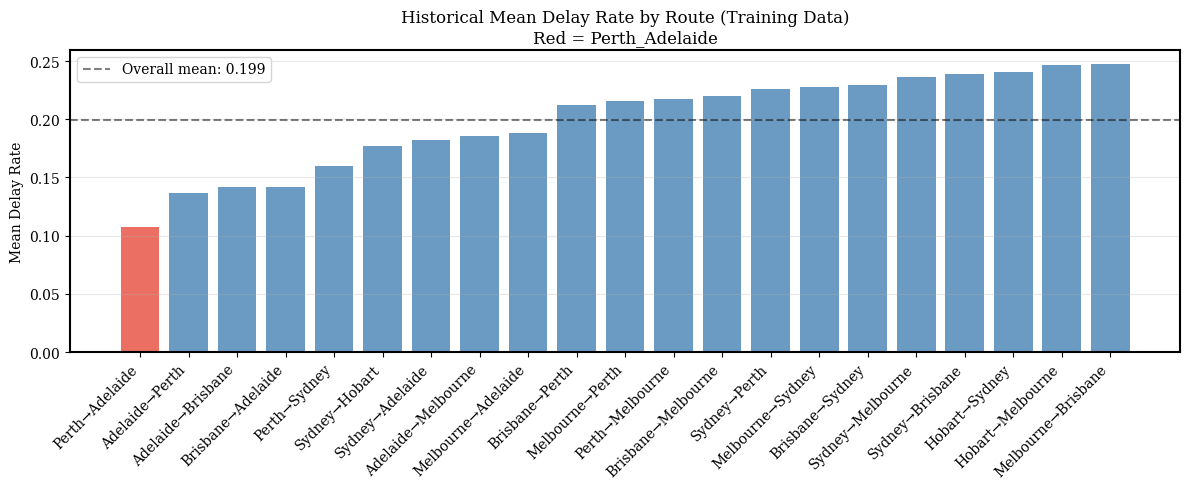

In [11]:
# Visualize route mean delay
fig, ax = plt.subplots(figsize=(12, 5))

route_means_sorted = route_mean_delay.sort_values()
colors = ['#e74c3c' if 'Perth_Adelaide' in r else 'steelblue' for r in route_means_sorted.index]

ax.bar(range(len(route_means_sorted)), route_means_sorted.values, color=colors, alpha=0.8)
ax.set_xticks(range(len(route_means_sorted)))
ax.set_xticklabels([r.replace('_', '→') for r in route_means_sorted.index], rotation=45, ha='right')
ax.set_ylabel('Mean Delay Rate')
ax.set_title('Historical Mean Delay Rate by Route (Training Data)\nRed = Perth_Adelaide')
ax.axhline(route_mean_delay.mean(), color='black', linestyle='--', alpha=0.5, label=f'Overall mean: {route_mean_delay.mean():.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Define Feature Sets

Compare baseline features (8b) with the new route mean feature.

In [12]:
# Baseline features (same as 8b)
base_features = airline_cols + route_cols + ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled']
weather_features = ['rainy_days_arr_exp', 'delay_rate_gradient', 'temp_volatility_total_exp', 'extreme_weather_days_total']
holiday_features = ['n_public_holidays_total', 'pct_school_holiday']

BASELINE_FEATURES = base_features + weather_features + holiday_features

# New features with route mean
NEW_FEATURES = BASELINE_FEATURES + ['route_mean_delay']

print(f"Baseline features: {len(BASELINE_FEATURES)}")
print(f"New features:      {len(NEW_FEATURES)} (+1 route_mean_delay)")

Baseline features: 38
New features:      39 (+1 route_mean_delay)


In [13]:
# Prepare data for both feature sets
X_train_base = df_clean.loc[train_mask, BASELINE_FEATURES].values
X_val_base = df_clean.loc[val_mask, BASELINE_FEATURES].values
X_test_base = df_clean.loc[test_mask, BASELINE_FEATURES].values

X_train_new = df_clean.loc[train_mask, NEW_FEATURES].values
X_val_new = df_clean.loc[val_mask, NEW_FEATURES].values
X_test_new = df_clean.loc[test_mask, NEW_FEATURES].values

y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
y_val_reg = df_clean.loc[val_mask, 'delay_rate'].values
y_test_reg = df_clean.loc[test_mask, 'delay_rate'].values

y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
y_val_clf = df_clean.loc[val_mask, 'is_high_delay'].values
y_test_clf = df_clean.loc[test_mask, 'is_high_delay'].values

# Scale features
scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_val_base_scaled = scaler_base.transform(X_val_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

scaler_new = StandardScaler()
X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_val_new_scaled = scaler_new.transform(X_val_new)
X_test_new_scaled = scaler_new.transform(X_test_new)

print("Data prepared.")
print(f"X_train_base: {X_train_base.shape}, X_train_new: {X_train_new.shape}")

Data prepared.
X_train_base: (6835, 38), X_train_new: (6835, 39)


## 5. Model Comparison

In [14]:
results = {'baseline': {}, 'with_route_mean': {}}

# Ridge Regression - Baseline
ridge_base = Ridge(alpha=100)
ridge_base.fit(X_train_base_scaled, y_train_reg)
results['baseline']['Ridge'] = {
    'val_r2': r2_score(y_val_reg, ridge_base.predict(X_val_base_scaled)),
    'test_r2': r2_score(y_test_reg, ridge_base.predict(X_test_base_scaled))
}

# Ridge Regression - With route mean
ridge_new = Ridge(alpha=100)
ridge_new.fit(X_train_new_scaled, y_train_reg)
results['with_route_mean']['Ridge'] = {
    'val_r2': r2_score(y_val_reg, ridge_new.predict(X_val_new_scaled)),
    'test_r2': r2_score(y_test_reg, ridge_new.predict(X_test_new_scaled))
}

print("Ridge Regression trained.")

Ridge Regression trained.


In [15]:
# Random Forest Regression - Baseline
rf_base = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_base.fit(X_train_base, y_train_reg)
results['baseline']['RF_Reg'] = {
    'val_r2': r2_score(y_val_reg, rf_base.predict(X_val_base)),
    'test_r2': r2_score(y_test_reg, rf_base.predict(X_test_base))
}

# Random Forest Regression - With route mean
rf_new = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_new.fit(X_train_new, y_train_reg)
results['with_route_mean']['RF_Reg'] = {
    'val_r2': r2_score(y_val_reg, rf_new.predict(X_val_new)),
    'test_r2': r2_score(y_test_reg, rf_new.predict(X_test_new))
}

print("Random Forest Regression trained.")

Random Forest Regression trained.


In [16]:
# Logistic Regression - Baseline
logreg_base = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg_base.fit(X_train_base_scaled, y_train_clf)
results['baseline']['Logistic'] = {
    'val_f1': f1_score(y_val_clf, logreg_base.predict(X_val_base_scaled)),
    'test_f1': f1_score(y_test_clf, logreg_base.predict(X_test_base_scaled))
}

# Logistic Regression - With route mean
logreg_new = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg_new.fit(X_train_new_scaled, y_train_clf)
results['with_route_mean']['Logistic'] = {
    'val_f1': f1_score(y_val_clf, logreg_new.predict(X_val_new_scaled)),
    'test_f1': f1_score(y_test_clf, logreg_new.predict(X_test_new_scaled))
}

print("Logistic Regression trained.")

Logistic Regression trained.


In [17]:
# XGBoost Classification
if HAS_XGB:
    # Baseline
    xgb_base = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                  min_child_weight=5, random_state=42, n_jobs=-1)
    xgb_base.fit(X_train_base, y_train_clf, eval_set=[(X_val_base, y_val_clf)], verbose=False)
    results['baseline']['XGBoost'] = {
        'val_f1': f1_score(y_val_clf, xgb_base.predict(X_val_base)),
        'test_f1': f1_score(y_test_clf, xgb_base.predict(X_test_base))
    }
    
    # With route mean
    xgb_new = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                 min_child_weight=5, random_state=42, n_jobs=-1)
    xgb_new.fit(X_train_new, y_train_clf, eval_set=[(X_val_new, y_val_clf)], verbose=False)
    results['with_route_mean']['XGBoost'] = {
        'val_f1': f1_score(y_val_clf, xgb_new.predict(X_val_new)),
        'test_f1': f1_score(y_test_clf, xgb_new.predict(X_test_new))
    }
    
    print("XGBoost trained.")

XGBoost trained.


## 6. Results Comparison

In [18]:
print("=" * 90)
print("REGRESSION RESULTS")
print("=" * 90)
print(f"{'Model':<15} {'Baseline Val':>12} {'New Val':>12} {'Δ Val':>10} {'Baseline Test':>14} {'New Test':>12} {'Δ Test':>10}")
print("-" * 90)

for model in ['Ridge', 'RF_Reg']:
    base_val = results['baseline'][model]['val_r2']
    new_val = results['with_route_mean'][model]['val_r2']
    base_test = results['baseline'][model]['test_r2']
    new_test = results['with_route_mean'][model]['test_r2']
    
    print(f"{model:<15} {base_val:>12.4f} {new_val:>12.4f} {new_val - base_val:>+10.4f} {base_test:>14.4f} {new_test:>12.4f} {new_test - base_test:>+10.4f}")

print("\n" + "=" * 90)
print("CLASSIFICATION RESULTS")
print("=" * 90)
print(f"{'Model':<15} {'Baseline Val':>12} {'New Val':>12} {'Δ Val':>10} {'Baseline Test':>14} {'New Test':>12} {'Δ Test':>10}")
print("-" * 90)

for model in ['Logistic', 'XGBoost']:
    if model not in results['baseline']:
        continue
    base_val = results['baseline'][model]['val_f1']
    new_val = results['with_route_mean'][model]['val_f1']
    base_test = results['baseline'][model]['test_f1']
    new_test = results['with_route_mean'][model]['test_f1']
    
    print(f"{model:<15} {base_val:>12.4f} {new_val:>12.4f} {new_val - base_val:>+10.4f} {base_test:>14.4f} {new_test:>12.4f} {new_test - base_test:>+10.4f}")

REGRESSION RESULTS
Model           Baseline Val      New Val      Δ Val  Baseline Test     New Test     Δ Test
------------------------------------------------------------------------------------------
Ridge                 0.4099       0.4099    +0.0000         0.4618       0.4617    -0.0001
RF_Reg                0.4148       0.4215    +0.0067         0.4858       0.4830    -0.0028

CLASSIFICATION RESULTS
Model           Baseline Val      New Val      Δ Val  Baseline Test     New Test     Δ Test
------------------------------------------------------------------------------------------
Logistic              0.6821       0.6821    +0.0000         0.7062       0.7062    +0.0000
XGBoost               0.7139       0.7148    +0.0009         0.7328       0.7377    +0.0048


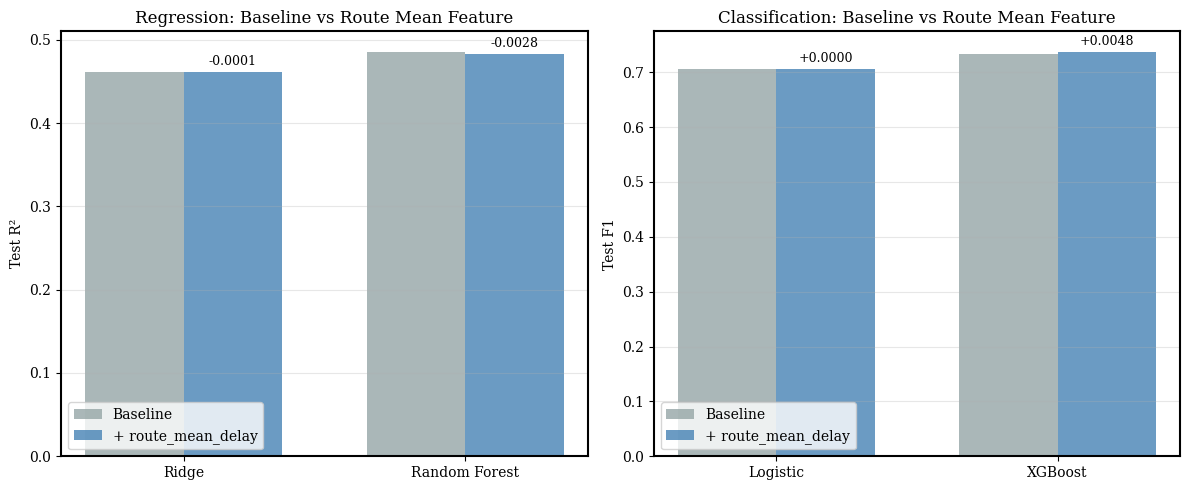

In [19]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression
ax = axes[0]
models_reg = ['Ridge', 'RF_Reg']
x = np.arange(len(models_reg))
width = 0.35

baseline_r2 = [results['baseline'][m]['test_r2'] for m in models_reg]
new_r2 = [results['with_route_mean'][m]['test_r2'] for m in models_reg]

ax.bar(x - width/2, baseline_r2, width, label='Baseline', color='#95a5a6', alpha=0.8)
ax.bar(x + width/2, new_r2, width, label='+ route_mean_delay', color='steelblue', alpha=0.8)

ax.set_ylabel('Test R²')
ax.set_title('Regression: Baseline vs Route Mean Feature')
ax.set_xticks(x)
ax.set_xticklabels(['Ridge', 'Random Forest'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (b, n) in enumerate(zip(baseline_r2, new_r2)):
    delta = n - b
    ax.annotate(f'{delta:+.4f}', xy=(i + width/2, n), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=9)

# Classification
ax = axes[1]
models_clf = ['Logistic']
if HAS_XGB:
    models_clf.append('XGBoost')

x = np.arange(len(models_clf))
baseline_f1 = [results['baseline'][m]['test_f1'] for m in models_clf]
new_f1 = [results['with_route_mean'][m]['test_f1'] for m in models_clf]

ax.bar(x - width/2, baseline_f1, width, label='Baseline', color='#95a5a6', alpha=0.8)
ax.bar(x + width/2, new_f1, width, label='+ route_mean_delay', color='steelblue', alpha=0.8)

ax.set_ylabel('Test F1')
ax.set_title('Classification: Baseline vs Route Mean Feature')
ax.set_xticks(x)
ax.set_xticklabels(models_clf)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (b, n) in enumerate(zip(baseline_f1, new_f1)):
    delta = n - b
    ax.annotate(f'{delta:+.4f}', xy=(i + width/2, n), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Route-Level Analysis

Check if the route mean feature improves predictions for specific routes (especially Perth_Adelaide).

In [20]:
# Get predictions for test set
df_test = df_clean[test_mask].copy()
df_test['ridge_base_pred'] = ridge_base.predict(X_test_base_scaled)
df_test['ridge_new_pred'] = ridge_new.predict(X_test_new_scaled)

print("Route-Level Performance Comparison (Ridge):")
print("=" * 80)
print(f"{'Route':<25} {'Baseline R²':>12} {'New R²':>12} {'Δ R²':>10} {'Variance':>10}")
print("-" * 80)

route_comparison = []
for route in sorted(df_test['route'].unique()):
    route_data = df_test[df_test['route'] == route]
    base_r2 = r2_score(route_data['delay_rate'], route_data['ridge_base_pred'])
    new_r2 = r2_score(route_data['delay_rate'], route_data['ridge_new_pred'])
    variance = route_data['delay_rate'].var()
    delta = new_r2 - base_r2
    
    marker = " ***" if 'Perth_Adelaide' in route else ""
    print(f"{route:<25} {base_r2:>12.4f} {new_r2:>12.4f} {delta:>+10.4f} {variance:>10.4f}{marker}")
    
    route_comparison.append({
        'route': route,
        'base_r2': base_r2,
        'new_r2': new_r2,
        'delta': delta,
        'variance': variance
    })

route_comp_df = pd.DataFrame(route_comparison)

Route-Level Performance Comparison (Ridge):
Route                      Baseline R²       New R²       Δ R²   Variance
--------------------------------------------------------------------------------
Adelaide_Brisbane               0.4051       0.4049    -0.0002     0.0328
Adelaide_Melbourne              0.4841       0.4840    -0.0001     0.0120
Adelaide_Perth                  0.5337       0.5335    -0.0002     0.0116
Brisbane_Adelaide               0.2428       0.2427    -0.0002     0.0168
Brisbane_Melbourne              0.3501       0.3500    -0.0001     0.0151
Brisbane_Perth                  0.2642       0.2642    +0.0000     0.0257
Brisbane_Sydney                 0.3369       0.3370    +0.0001     0.0079
Hobart_Melbourne                0.5661       0.5660    -0.0001     0.0148
Hobart_Sydney                   0.3660       0.3661    +0.0002     0.0086
Melbourne_Adelaide              0.4441       0.4439    -0.0001     0.0098
Melbourne_Brisbane              0.2029       0.2028    -0.000

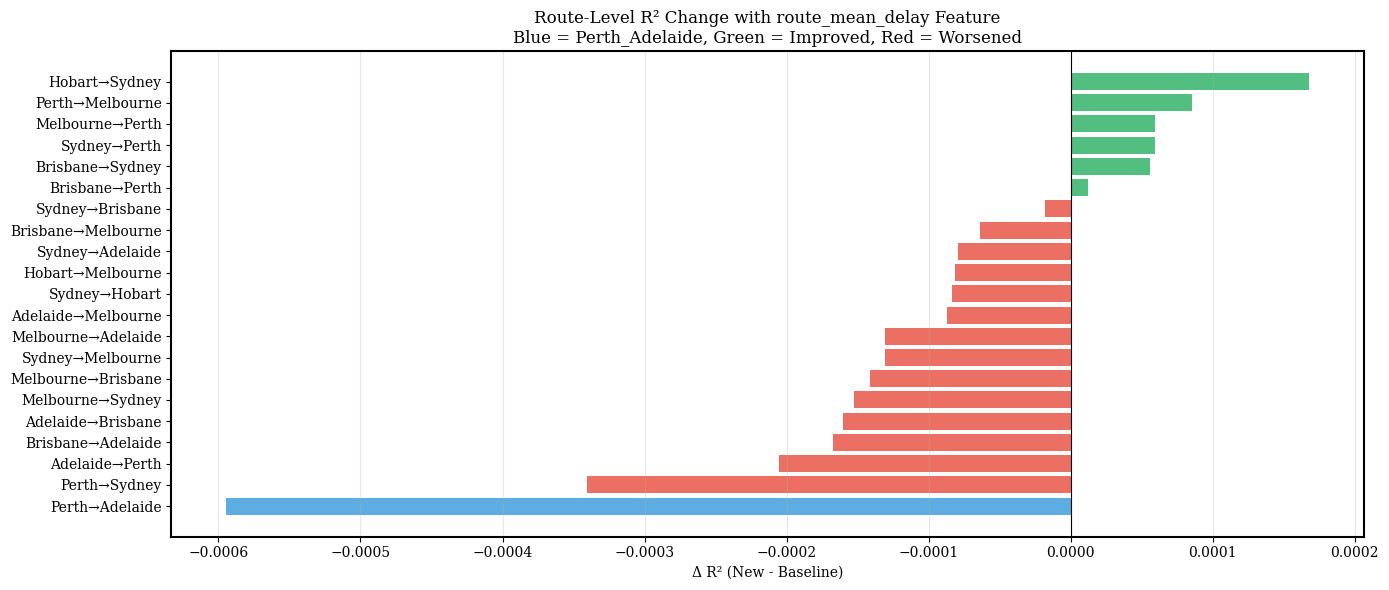

In [21]:
# Visualize route-level improvements
fig, ax = plt.subplots(figsize=(14, 6))

route_comp_df_sorted = route_comp_df.sort_values('delta')
routes = route_comp_df_sorted['route'].values
deltas = route_comp_df_sorted['delta'].values

colors = ['#27ae60' if d > 0 else '#e74c3c' for d in deltas]
# Highlight Perth_Adelaide
colors = ['#3498db' if 'Perth_Adelaide' in r else c for r, c in zip(routes, colors)]

ax.barh(range(len(routes)), deltas, color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_yticks(range(len(routes)))
ax.set_yticklabels([r.replace('_', '→') for r in routes])
ax.set_xlabel('Δ R² (New - Baseline)')
ax.set_title('Route-Level R² Change with route_mean_delay Feature\nBlue = Perth_Adelaide, Green = Improved, Red = Worsened')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

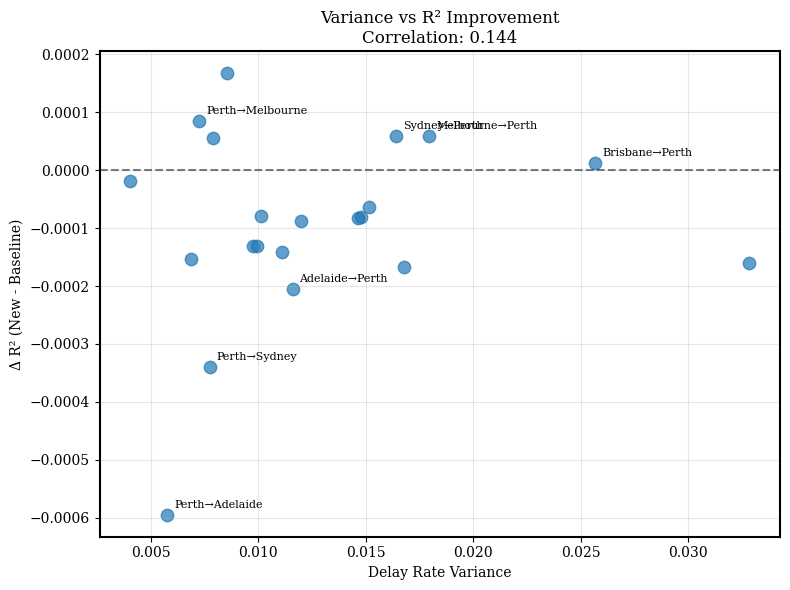

Correlation between variance and improvement: 0.1444
No strong relationship between variance and improvement.


In [22]:
# Check correlation between variance and improvement
correlation = route_comp_df['variance'].corr(route_comp_df['delta'])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(route_comp_df['variance'], route_comp_df['delta'], s=80, alpha=0.7)

# Label Perth_Adelaide
for _, row in route_comp_df.iterrows():
    if 'Perth' in row['route']:
        ax.annotate(row['route'].replace('_', '→'), 
                    xy=(row['variance'], row['delta']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Delay Rate Variance')
ax.set_ylabel('Δ R² (New - Baseline)')
ax.set_title(f'Variance vs R² Improvement\nCorrelation: {correlation:.3f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation between variance and improvement: {correlation:.4f}")
if correlation < -0.3:
    print("Low-variance routes tend to benefit more from the route mean feature.")
elif correlation > 0.3:
    print("High-variance routes tend to benefit more from the route mean feature.")
else:
    print("No strong relationship between variance and improvement.")

## 8. Feature Importance

In [23]:
# Feature importance from Random Forest with new feature
importance_df = pd.DataFrame({
    'Feature': NEW_FEATURES,
    'Importance': rf_new.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest with route_mean_delay):")
print("-" * 50)
for i, row in importance_df.head(15).iterrows():
    marker = " <<<" if row['Feature'] == 'route_mean_delay' else ""
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}{marker}")

# Find rank of route_mean_delay
rank = importance_df.reset_index(drop=True)
rank['rank'] = rank.index + 1
route_mean_rank = rank[rank['Feature'] == 'route_mean_delay']['rank'].values[0]
route_mean_importance = rank[rank['Feature'] == 'route_mean_delay']['Importance'].values[0]

print(f"\nroute_mean_delay rank: {route_mean_rank}/{len(NEW_FEATURES)}")
print(f"route_mean_delay importance: {route_mean_importance:.4f}")

Feature Importance (Random Forest with route_mean_delay):
--------------------------------------------------
  delay_rate_lag1                     0.6703
  delay_rate_gradient                 0.0571
  rainy_days_arr_exp                  0.0530
  sectors_scheduled                   0.0360
  route_mean_delay                    0.0328 <<<
  temp_volatility_total_exp           0.0305
  pct_school_holiday                  0.0229
  extreme_weather_days_total          0.0222
  month_sin                           0.0214
  n_public_holidays_total             0.0141
  month_cos                           0.0120
  airline_Jetstar                     0.0068
  airline_Virgin Australia            0.0033
  route_Brisbane_Perth                0.0025
  airline_Qantas                      0.0019

route_mean_delay rank: 5/39
route_mean_delay importance: 0.0328


## 9. Summary and Observations

In [ ]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)

# Calculate average improvements
reg_improvements = [
    results['with_route_mean']['Ridge']['test_r2'] - results['baseline']['Ridge']['test_r2'],
    results['with_route_mean']['RF_Reg']['test_r2'] - results['baseline']['RF_Reg']['test_r2']
]
clf_improvements = [
    results['with_route_mean']['Logistic']['test_f1'] - results['baseline']['Logistic']['test_f1']
]
if HAS_XGB:
    clf_improvements.append(
        results['with_route_mean']['XGBoost']['test_f1'] - results['baseline']['XGBoost']['test_f1']
    )

# Route-level summary
routes_improved = (route_comp_df['delta'] > 0.01).sum()
routes_worsened = (route_comp_df['delta'] < -0.01).sum()
routes_unchanged = len(route_comp_df) - routes_improved - routes_worsened

print(f"""
FEATURE: route_mean_delay
  Historical mean delay rate per route (calculated from training data only)

OVERALL IMPACT:
  Regression (Test R²):
    - Ridge:         {reg_improvements[0]:+.4f}
    - Random Forest: {reg_improvements[1]:+.4f}
    - Average:       {np.mean(reg_improvements):+.4f}
  
  Classification (Test F1):
    - Logistic:      {clf_improvements[0]:+.4f}""")

if HAS_XGB:
    print(f"    - XGBoost:       {clf_improvements[1]:+.4f}")

print(f"    - Average:       {np.mean(clf_improvements):+.4f}")

print(f"""
ROUTE-LEVEL IMPACT (Ridge):
  Routes improved (Δ R² > 0.01):  {routes_improved}
  Routes worsened (Δ R² < -0.01): {routes_worsened}
  Routes unchanged:               {routes_unchanged}

PERTH_ADELAIDE SPECIFICALLY:""")

perth_row = route_comp_df[route_comp_df['route'] == 'Perth_Adelaide'].iloc[0]
print(f"  Baseline R²: {perth_row['base_r2']:.4f}")
print(f"  New R²:      {perth_row['new_r2']:.4f}")
print(f"  Δ R²:        {perth_row['delta']:+.4f}")

SUMMARY

FEATURE: route_mean_delay
  Historical mean delay rate per route (calculated from training data only)

OVERALL IMPACT:
  Regression (Test R²):
    - Ridge:         -0.0001
    - Random Forest: -0.0028
    - Average:       -0.0014

  Classification (Test F1):
    - Logistic:      +0.0000
    - XGBoost:       +0.0048
    - Average:       +0.0024

ROUTE-LEVEL IMPACT (Ridge):
  Routes improved (Δ R² > 0.01):  0
  Routes worsened (Δ R² < -0.01): 0
  Routes unchanged:               21

PERTH_ADELAIDE SPECIFICALLY:
  Baseline R²: 0.1391
  New R²:      0.1385
  Δ R²:        -0.0006

RECOMMENDATION:
  Marginal impact (+0.0005) — include if interpretability is valued,
  as it provides explicit route-level bias that may help with low-variance routes.


## Observations

- Very marginal changes for all models
- Best guess is that the individual biases have been taken into account by on-hot encoding the routes.

## 10. Next Step

The next step will be developing a Streamlit app, which provides a user-friendly interface to access the model predictions and also re-training using updated data.